In [1]:
import kagglehub
import pandas as pd
import numpy as np
import os

try:
    path = kagglehub.dataset_download("chethuhn/network-intrusion-dataset")
    data = pd.read_csv(os.path.join(path, 'Friday-WorkingHours-Morning.pcap_ISCX.csv'))
    print(" Path to dataset files:", path)
    
except Exception as e:
    print(f"Something failed... {e}")

data.head()

 Path to dataset files: /Users/antoniogonzalez/.cache/kagglehub/datasets/chethuhn/network-intrusion-dataset/versions/1


,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,3268,112740690,32,16,6448,1152,403,0,201.5,204.724205,...,32,3.594286e+02,1.199802e+01,380,343,16100000.0,4.988048e+05,16400000,15400000,BENIGN
1,389,112740560,32,16,6448,5056,403,0,201.5,204.724205,...,32,3.202857e+02,1.574499e+01,330,285,16100000.0,4.987937e+05,16400000,15400000,BENIGN
2,0,113757377,545,0,0,0,0,0,0.0,0.000000,...,0,9.361829e+06,7.324646e+06,18900000,19,12200000.0,6.935824e+06,20800000,5504997,BENIGN
3,5355,100126,22,0,616,0,28,28,28.0,0.000000,...,32,0.000000e+00,0.000000e+00,0,0,0.0,0.000000e+00,0,0,BENIGN
4,0,54760,4,0,0,0,0,0,0.0,0.000000,...,0,0.000000e+00,0.000000e+00,0,0,0.0,0.000000e+00,0,0,BENIGN


In [2]:
data.columns = data.columns.str.strip()

print(data.shape)

print(data.dtypes)

(191033, 79)
Destination Port                 int64
Flow Duration                    int64
Total Fwd Packets                int64
Total Backward Packets           int64
Total Length of Fwd Packets      int64
                                ...   
Idle Mean                      float64
Idle Std                       float64
Idle Max                         int64
Idle Min                         int64
Label                           object
Length: 79, dtype: object


In [3]:
print(data.isnull().sum())
print('----')
print(data['Label'].value_counts())

num_port = {}
count = {}

for label, port in zip(data['Label'], data['Destination Port']):
    if label not in num_port:
        num_port[label] = []
    num_port[label].append(port)

for label, ports in num_port.items():
    count = {}
    for port in ports:
        if port not in count:
            count[port] = 0
        count[port] += 1
    most_common_port = max(count, key=count.get)
    least_common_port = min(count, key=count.get)
    other_ports = [port for port, hits in count.items() if port not in [most_common_port, least_common_port]]
    print(f"Label: {label}, Most Common Destination Port: {most_common_port}, Hits: {count[most_common_port]}")
    print(f"Label: {label}, Least Common Destination Port: {least_common_port}, Hits: {count[least_common_port]}")
    print(f"Label: {label}, Other Destination Ports: {other_ports}")
    print("-----")

Destination Port               0
Flow Duration                  0
Total Fwd Packets              0
Total Backward Packets         0
Total Length of Fwd Packets    0
                              ..
Idle Mean                      0
Idle Std                       0
Idle Max                       0
Idle Min                       0
Label                          0
Length: 79, dtype: int64
----
Label
BENIGN    189067
Bot         1966
Name: count, dtype: int64
Label: BENIGN, Most Common Destination Port: 53, Hits: 90277
Label: BENIGN, Least Common Destination Port: 49420, Hits: 1
Label: BENIGN, Other Destination Ports: [3268, 389, 0, 5355, 88, 1031, 1034, 135, 49671, 137, 445, 138, 5353, 123, 49415, 49666, 49168, 49175, 53408, 49171, 443, 80, 1028, 1029, 7725, 49954, 1043, 1051, 1054, 49157, 49158, 1047, 5215, 5213, 49422, 49412, 8612, 49184, 139, 49162, 3289, 1040, 1124, 49167, 49413, 51958, 1061, 49186, 49185, 49187, 1900, 49188, 49189, 39269, 21, 1062, 1063, 22, 1058, 1041, 465, 1064, 103

In [4]:

from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

columns_drop = [
    'Fwd Header Length.1'
]


data['Label'] = le.fit_transform(data['Label'])

data.replace([np.inf, -np.inf], np.nan, inplace=True)
data.dropna(inplace=True)

data = data.drop(columns=columns_drop, errors='ignore')

X = data.drop('Label', axis=1)
y = data['Label']

In [5]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.8, test_size=0.2, random_state=1)

In [6]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

model = RandomForestClassifier(n_estimators=100, random_state=1)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     37759
           1       1.00      0.96      0.98       424

    accuracy                           1.00     38183
   macro avg       1.00      0.98      0.99     38183
weighted avg       1.00      1.00      1.00     38183



Init_Win_bytes_forward     0.161348
Destination Port           0.114385
Init_Win_bytes_backward    0.057552
Bwd IAT Min                0.035040
Bwd Packets/s              0.031665
Bwd IAT Mean               0.028899
Flow Packets/s             0.028195
Flow Duration              0.027749
Avg Bwd Segment Size       0.026923
Bwd Packet Length Mean     0.026710
dtype: float64


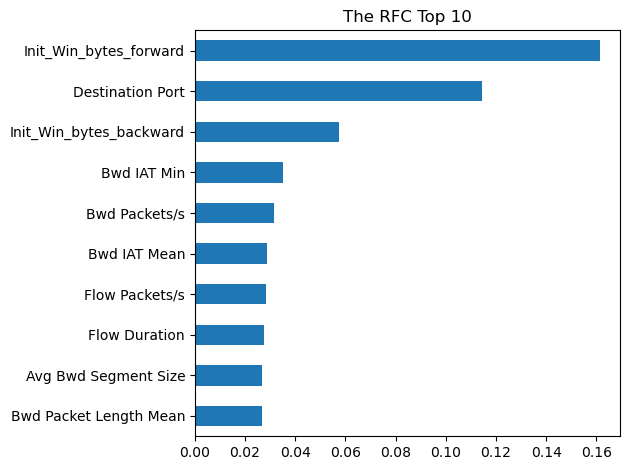

In [7]:
import matplotlib.pyplot as plt

rfc_importance = RandomForestClassifier(n_estimators = 100, random_state=1)
rfc_importance.fit(X,y)

importance = pd.Series(rfc_importance.feature_importances_, index=X.columns)
print(importance.nlargest(10))

importance.nlargest(10).sort_values().plot(kind='barh')
plt.title('The RFC Top 10')
plt.tight_layout()
plt.show()